<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
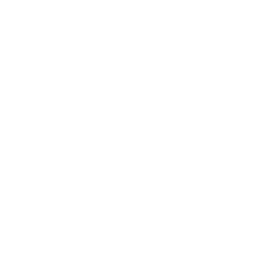
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analyse af stemmemønster i valgdistrikter</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Offentlig sektor / valgstatistik &nbsp;|&nbsp; Marts 2026</p>
</div>
</div>
</div>

## Resumé

Denne analyse undersøger, om partitilslutning varierer systematisk på
tværs af distriktstyper (by, forstad, land) i et simuleret
amts-/kommunevalgdatasæt med 100 valgdistrikter. Fordi flere
parti-gange-distriktstype-celler er sparsomme — de mindste celler i
kontingenstabellen indeholder kun ét eller to distrikter, med forventede
antal under fem — er den generelle Pearson chi-i-anden-test for
association underpowered og upålidelig her. Vi supplerer den derfor med
**Cochran-Armitage-trendtesten**, en fokuseret test med én frihedsgrad,
der udnytter den naturlige by-til-land-ordning og stiller et skarpere
spørgsmål: falder Parti A's opbakning monotont langs den gradient?
Trendtesten rapporterer en eksakt p-værdi, hvilket er den rette
inferens, når celletællingerne er små. Kontrasten mellem de to test er
denne eksempels analytiske pointe: en generisk associationstest kan
overse et reelt retningsbestemt mønster, som en ordnet trendtest
opdager.

## Datakilder

| Kilde | Beskrivelse | Poster |
|--------|-------------|--------|
| WORK.PRECINCT_VOTES | Distriktsniveau-records, én række pr. valgdistrikt, med distriktstype, kommune og det parti, der fik flest stemmer | 100 |

Runtime kører i ulicenseret tilstand, hvilket begrænser output til 100
observationer; analysen er designet omkring dette distriktsniveau-udsnit,
så kontingenstabellens celler er ægte små, og den eksakte trendtest er
det naturlige værktøj.

---

In [1]:
/* --------------------------------------------------------
   Generér syntetisk distriktsniveau-stemmedata.
   Små celletællinger i landdistrikter for at demonstrere
   behovet for eksakte test.
   -------------------------------------------------------- */
data work.precinct_votes;
    CALL streaminit(42);
    TABEL party_list[4] $15 _temporary_ ('PARTI_A' 'PARTI_B' 'PARTI_C' 'UAFHÆNGIG');
    TABEL type_list[3] $10 _temporary_ ('BY' 'FORSTAD' 'LAND');
    TABEL county_list[5] $15 _temporary_ ('AALBORG' 'AARHUS' 'ESBJERG' 'KOLDING' 'RANDERS');
    LÆNGDE precinct_type $10;
    LÆNGDE party $15;
    GØR precinct_seq = 1 TIL 500;
        precinct_id = cat('PCT-', SKRIV_V(precinct_seq, z4.));
        county_idx = int(rand('uniform') * 5) + 1;
        county_name = county_list[county_idx];
        /* Tildel distriktstype med vægtning */
        type_prob = rand('uniform');
        HVIS type_prob < 0.30 SÅ precinct_type = 'BY';
        ELLERS HVIS type_prob < 0.65 SÅ precinct_type = 'FORSTAD';
        ELLERS precinct_type = 'LAND';
        /* Tildel parti med distriktstype-afhængig fordeling */
        party_prob = rand('uniform');
        HVIS precinct_type = 'BY' SÅ GØR;
            HVIS party_prob < 0.55 SÅ party = 'PARTI_A';
            ELLERS HVIS party_prob < 0.80 SÅ party = 'PARTI_B';
            ELLERS HVIS party_prob < 0.92 SÅ party = 'PARTI_C';
            ELLERS party = 'UAFHÆNGIG';
        SLUT;
        ELLERS HVIS precinct_type = 'FORSTAD' SÅ GØR;
            HVIS party_prob < 0.40 SÅ party = 'PARTI_A';
            ELLERS HVIS party_prob < 0.75 SÅ party = 'PARTI_B';
            ELLERS HVIS party_prob < 0.88 SÅ party = 'PARTI_C';
            ELLERS party = 'UAFHÆNGIG';
        SLUT;
        ELLERS GØR; /* LAND - mindre celler for minoritetspartier */
            HVIS party_prob < 0.25 SÅ party = 'PARTI_A';
            ELLERS HVIS party_prob < 0.70 SÅ party = 'PARTI_B';
            ELLERS HVIS party_prob < 0.85 SÅ party = 'PARTI_C';
            ELLERS party = 'UAFHÆNGIG';
        SLUT;
        /* Stemmetal varierer efter distriktstype */
        HVIS precinct_type = 'BY' SÅ
            vote_count = int(rand('normal', 120, 40));
        ELLERS HVIS precinct_type = 'FORSTAD' SÅ
            vote_count = int(rand('normal', 80, 25));
        ELLERS
            vote_count = int(rand('normal', 25, 12));
        HVIS vote_count < 1 SÅ vote_count = 1;
        registered_voters = int(vote_count * (rand('uniform') * 0.4 + 1.2));
        turnout_pct = round(vote_count / registered_voters * 100, 0.1);
        election_year = 2026;
        UDDATA;
    SLUT;
    FJERN precinct_seq county_idx type_prob party_prob;
KØR;


NOTE: DATA work.precinct_votes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.precinct_votes (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.15 seconds
  cpu   0.15 seconds


---

                                                   The FREQ Procedure

Distriktstype    Frequency    Percent
--------------------------------------
BY                      29     29.00
FORSTAD                 37     37.00
LAND                    34     34.00

Parti         Frequency    Percent
-----------------------------------
PARTI_A              45     45.00
PARTI_B              34     34.00
PARTI_C              12     12.00
UAFHÆNGIG             9      9.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_precinct_type.spec.json
NOTE: ODS plot written: freq_party.spec.json
NOTE: PROC FREQ statement used.


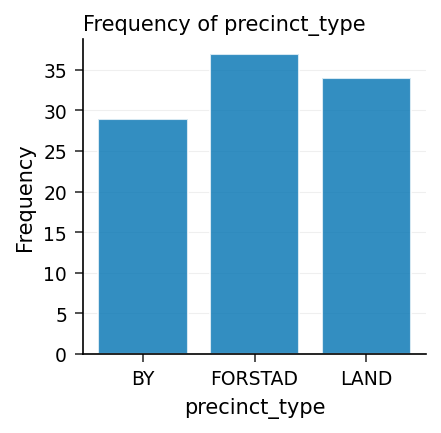

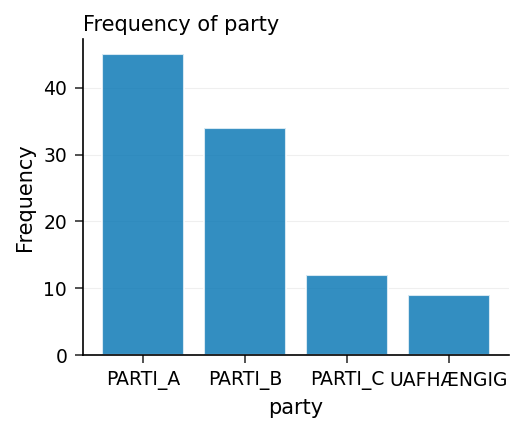

In [2]:
/* --------------------------------------------------------
   Baseline-fordeling af distriktstype og parti
   -------------------------------------------------------- */
PROCEDURE FREKVENSER data=work.precinct_votes;
    TABLES precinct_type / nocum;
    TABLES party / nocum;
    MÆRKAT precinct_type = "Distriktstype"
           party = "Parti";
KØR;

---


NOTE: PROC SGPLOT data=work.precinct_votes

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


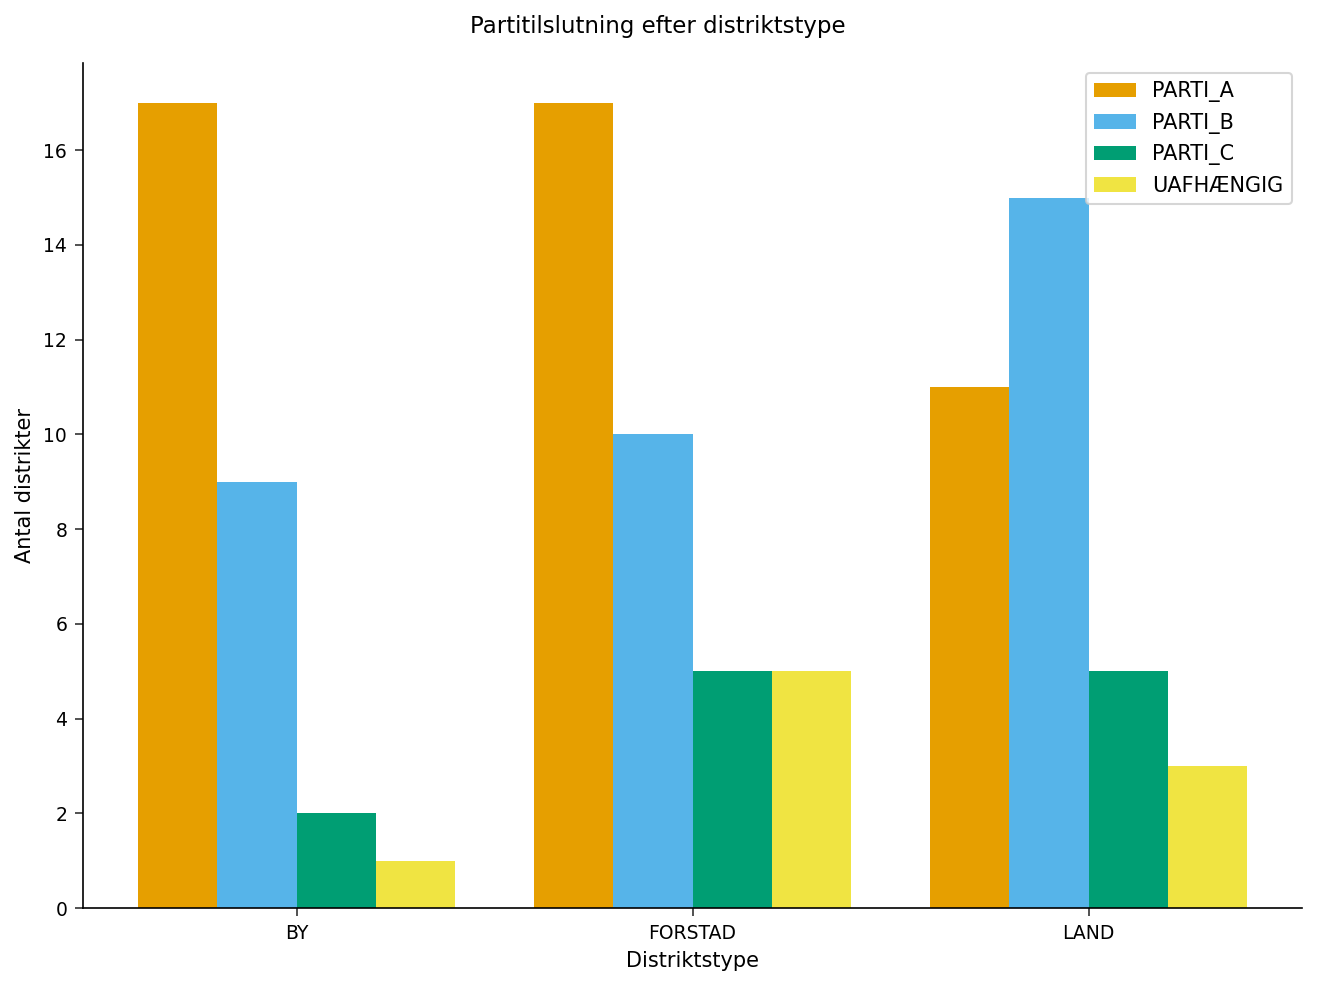

In [3]:
/* --------------------------------------------------------
   Partitilslutning efter distriktstype (antal distrikter)
   -------------------------------------------------------- */
PROCEDURE SGPLOT data=work.precinct_votes;
    VBAR precinct_type / GROUP=party GROUPDISPLAY=CLUSTER
        STAT=FREKVENSER;
    XAXIS MÆRKAT='Distriktstype';
    YAXIS MÆRKAT='Antal distrikter';
    TITEL 'Partitilslutning efter distriktstype';
KØR;

---

                            Distriktstype efter parti: krydstabulering med forventede antal                             

                                                   The FREQ Procedure

Table of Distriktstype by Parti

Distriktstype |   PARTI_A |   PARTI_B |   PARTI_C | UAFHÆNGIG |      Total
--------------+-----------+-----------+-----------+-----------+-----------
BY            |        17 |         9 |         2 |         1 |         29
              |     17.00 |      9.00 |      2.00 |      1.00 |      29.00
              |     13.05 |      9.86 |      3.48 |      2.61 |           
              |     58.62 |     31.03 |      6.90 |      3.45 |     100.00
              |     37.78 |     26.47 |     16.67 |     11.11 |      29.00
--------------+-----------+-----------+-----------+-----------+-----------
FORSTAD       |        17 |        10 |         5 |         5 |         37
              |     17.00 |     10.00 |      5.00 |      5.00 |      37.00
              |     16.6


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.


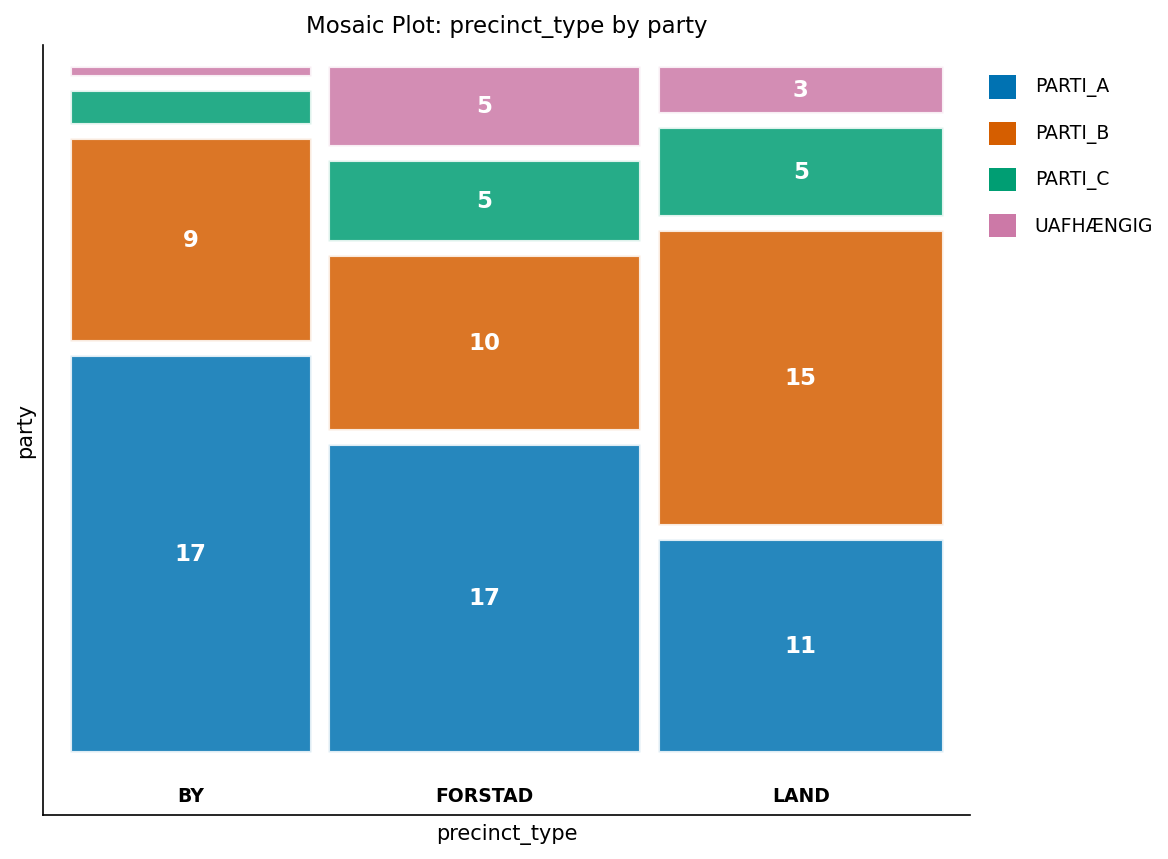

In [4]:
/* --------------------------------------------------------
   Krydstabulering af distriktstype x parti.
   Anmod om FORVENTEDE antal, så de sparsomme celler er
   synlige, plus den asymptotiske Pearson chi-i-anden-test for
   generel association. Bemærk de små forventede antal i
   kolonnerne UAFHÆNGIG og PARTI_C -- indikationen på, at en
   ordnet, eksakt trendtest er det bedre inferensværktøj.
   -------------------------------------------------------- */
PROCEDURE FREKVENSER data=work.precinct_votes;
    TABLES precinct_type * party / chisq expected;
    MÆRKAT precinct_type = "Distriktstype"
           party = "Parti";
    TITEL 'Distriktstype efter parti: krydstabulering med forventede antal';
KØR;

                   Cochran-Armitage-trendtest: Parti A-opbakning på tværs af urbaniseringsgradienten                    

                                                   The FREQ Procedure

Table of Urbaniseringsgrad by Parti A-tilslutning

Urbaniseringsgrad |         0 |         1 |      Total
------------------+-----------+-----------+-----------
1                 |        12 |        17 |         29
                  |     12.00 |     17.00 |      29.00
                  |     41.38 |     58.62 |     100.00
                  |     21.82 |     37.78 |      29.00
------------------+-----------+-----------+-----------
2                 |        20 |        17 |         37
                  |     20.00 |     17.00 |      37.00
                  |     54.05 |     45.95 |     100.00
                  |     36.36 |     37.78 |      37.00
------------------+-----------+-----------+-----------
3                 |        23 |        11 |         34
                  |     23.00 |     11.00


NOTE: DATA work.precinct_ordinal


NOTE: Read 100 rows from work.precinct_votes.
NOTE: Wrote work.precinct_ordinal (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_type_order_party_a_flag.spec.json
NOTE: PROC FREQ statement used.


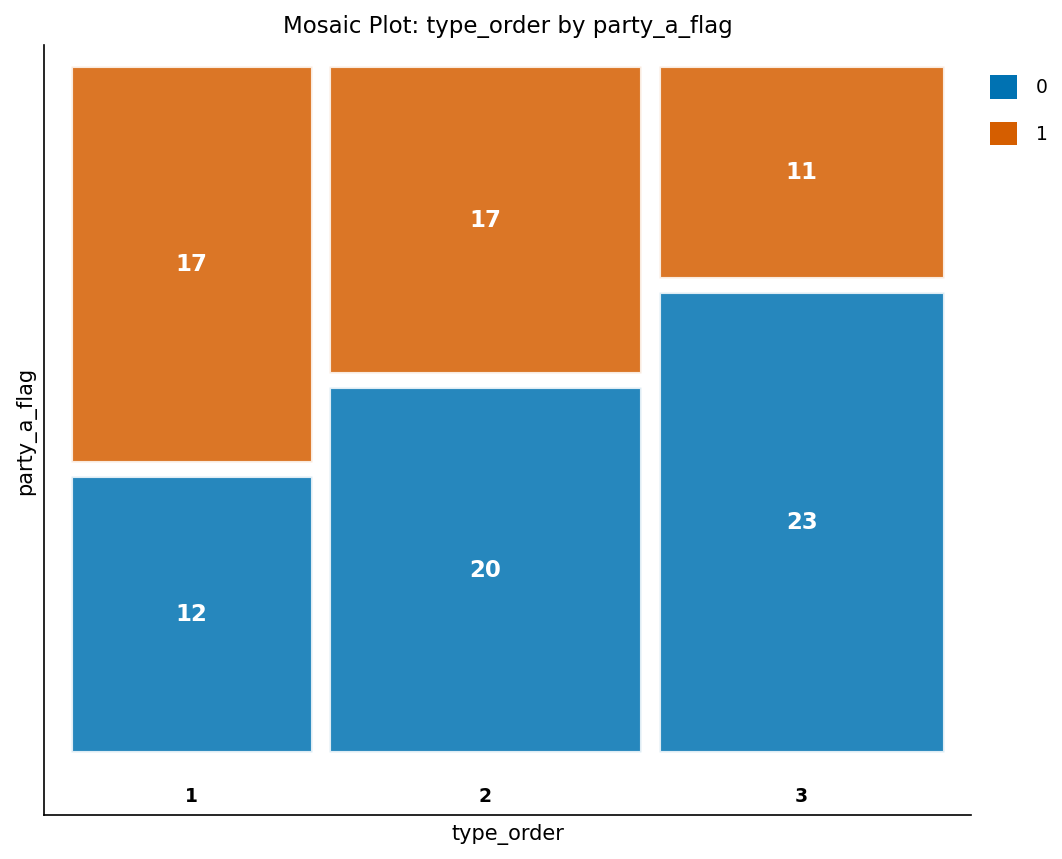

In [5]:
/* --------------------------------------------------------
   Cochran-Armitage-trendtest. Omkod distriktstype til en
   ordinal score (1=By, 2=Forstad, 3=Land) og test, om Parti
   A's opbakning viser en monoton trend på tværs af
   gradienten. EXACT TREND anmoder om den eksakte p-værdi,
   passende givet de små celletællinger.
   -------------------------------------------------------- */
data work.precinct_ordinal;
    SÆT work.precinct_votes;
    /* Ordinal kodning: 1=By, 2=Forstad, 3=Land */
    HVIS precinct_type = 'BY' SÅ type_order = 1;
    ELLERS HVIS precinct_type = 'FORSTAD' SÅ type_order = 2;
    ELLERS type_order = 3;
    /* Binært udfald: Parti A vs. alle andre tilslutninger */
    party_a_flag = (party = 'PARTI_A');
KØR;

PROCEDURE FREKVENSER data=work.precinct_ordinal;
    TABLES type_order * party_a_flag / chisq trend;
    EXACT trend;
    MÆRKAT type_order = "Urbaniseringsgrad"
           party_a_flag = "Parti A-tilslutning";
    TITEL 'Cochran-Armitage-trendtest: Parti A-opbakning på tværs af urbaniseringsgradienten';
KØR;

                                      Fordeling af distriktstype inden for kommune                                      

                                                   The FREQ Procedure

Table of Kommune by Distriktstype

Kommune |        BY |   FORSTAD |      LAND |      Total
--------+-----------+-----------+-----------+-----------
AALBORG |         7 |         7 |         4 |         18
        |      7.00 |      7.00 |      4.00 |      18.00
        |     38.89 |     38.89 |     22.22 |     100.00
        |     24.14 |     18.92 |     11.76 |      18.00
--------+-----------+-----------+-----------+-----------
AARHUS  |         7 |         7 |         7 |         21
        |      7.00 |      7.00 |      7.00 |      21.00
        |     33.33 |     33.33 |     33.33 |     100.00
        |     24.14 |     18.92 |     20.59 |      21.00
--------+-----------+-----------+-----------+-----------
ESBJERG |         9 |         1 |        13 |         23
        |      9.00 |      1.00


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_county_name_precinct_type.spec.json
NOTE: PROC FREQ statement used.


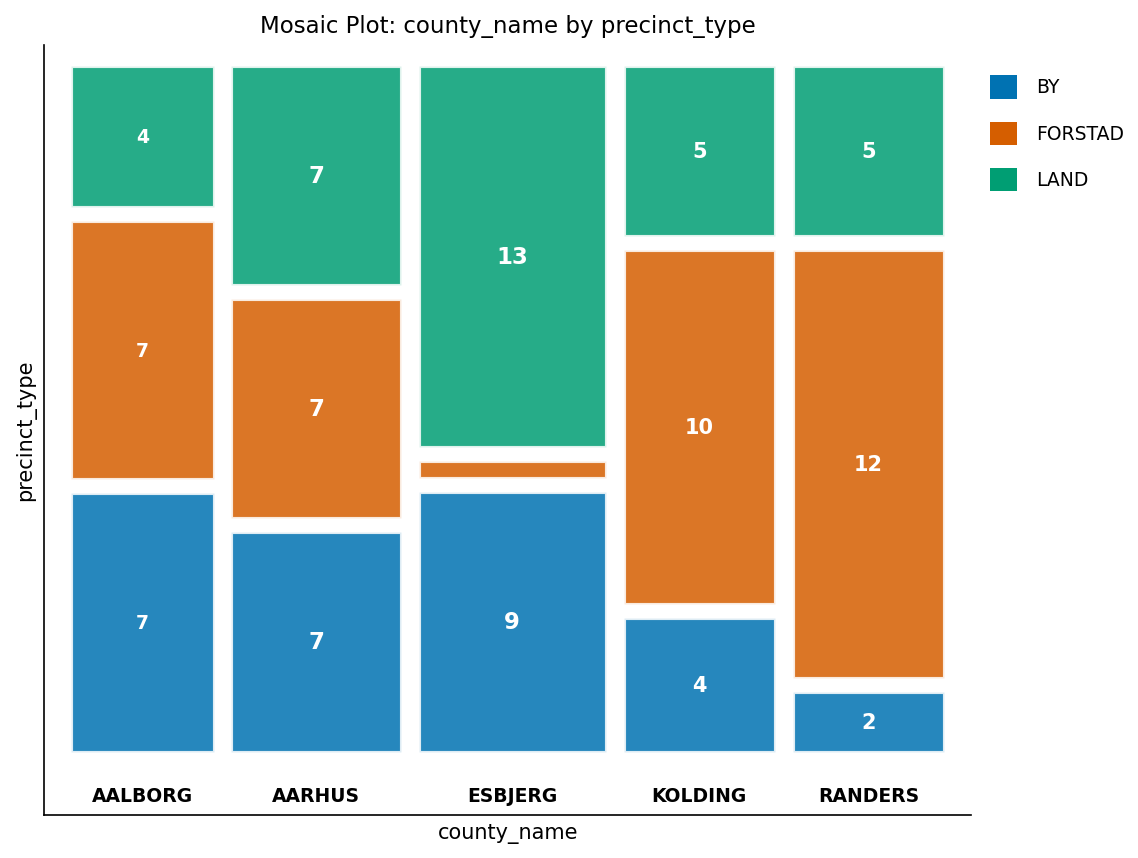

In [6]:
/* --------------------------------------------------------
   Kommuneniveau: hvordan by-/forstads-/landblandingen
   varierer på tværs af de fem kommuner. Dette
   kontekstualiserer trendresultatet -- distriktsgradienten er
   til stede i hver kommune, men dens sammensætning varierer.
   -------------------------------------------------------- */
PROCEDURE FREKVENSER data=work.precinct_votes;
    TABLES county_name * precinct_type / nocum;
    MÆRKAT county_name = "Kommune"
           precinct_type = "Distriktstype";
    TITEL 'Fordeling af distriktstype inden for kommune';
KØR;

---

### Fortolkning

På tværs af de 100 valgdistrikter har Parti A en samlet flerhed (45
distrikter), efterfulgt af Parti B (34), Parti C (12) og uafhængige (9).
Krydstabuleringen viser, at Parti A's andel følger en klar
by-til-land-gradient: det udgør 58.6% af bydistrikterne, 46.0% af
forstadsdistrikterne og 32.4% af landdistrikterne, mens Parti B bevæger
sig i den modsatte retning og stiger fra 31.0% i by til 44.1% på land.

Den generelle Pearson chi-i-anden-test for generel association er
**ikke** statistisk signifikant (chi-i-anden = 6.78, 6 df, p = 0.3418;
Cramérs V = 0.18). Det resultat er også skrøbeligt: visningen af
forventede antal afslører flere celler under fem — for eksempel har
kolonnen for uafhængige forventede antal på 3.06, 3.33 og 2.61, og
uafhængige i bydistrikter tæller kun ét distrikt — så
chi-i-anden-tilnærmelsen for store stikprøver er upålidelig her.

Cochran-Armitage-trendtesten skærper spørgsmålet ved at bruge den
ordinale by-forstad-land-scoring. Den opdager det monotone fald i Parti
A's opbakning, som den generelle test overser: trend-chi-i-anden = 4.38
med en asymptotisk Pr > ChiSq = 0.0363 og en **eksakt Pr >= |Z| =
0.0431**, signifikant på 0.05-niveauet. Dette er den analytiske gevinst
— en fokuseret, eksakt test med én frihedsgrad genfinder et reelt
retningsbestemt signal, som den generiske association-test med 6
frihedsgrader, svækket af sparsomme celler, ikke gør.

Kommuneniveau-visningen bekræfter, at by-/forstads-/land-opdelingen er
til stede i alle fem kommuner, selvom blandingen varierer: Esbjerg er
den mest landdistriktstunge (13 ud af 23 distrikter er land), mens
Randers er den mest forstadsprægede (12 ud af 19). For vurdering af
konsekvenserne af nye distriktsgrænser er pointen, at
grænseændringer, der flytter distrikter langs by-land-aksen, målbart vil
ændre den partipolitiske sammensætning, og at denne geografiske trend
bedst dokumenteres af den eksakte trendtest frem for den generelle
chi-i-anden-test.

---

                                      Fordeling af distriktstype inden for kommune                                      

                                                   The FREQ Procedure

Table of Distriktstype by Parti

Distriktstype |   PARTI_A |   PARTI_B |   PARTI_C | UAFHÆNGIG |      Total
--------------+-----------+-----------+-----------+-----------+-----------
BY            |        17 |         9 |         2 |         1 |         29
              |     17.00 |      9.00 |      2.00 |      1.00 |      29.00
              |     58.62 |     31.03 |      6.90 |      3.45 |     100.00
              |     37.78 |     26.47 |     16.67 |     11.11 |      29.00
--------------+-----------+-----------+-----------+-----------+-----------
FORSTAD       |        17 |        10 |         5 |         5 |         37
              |     17.00 |     10.00 |      5.00 |      5.00 |      37.00
              |     45.95 |     27.03 |     13.51 |     13.51 |     100.00
              |     37.7


NOTE: PROC FREQ
NOTE: Output dataset work.voting_pattern_summary has 12 observations and 4 variables.
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC EXPORT data=work.voting_pattern_summary outfile=precinct_voting_patterns.csv

NOTE: Exported 12 rows to precinct_voting_patterns.csv.


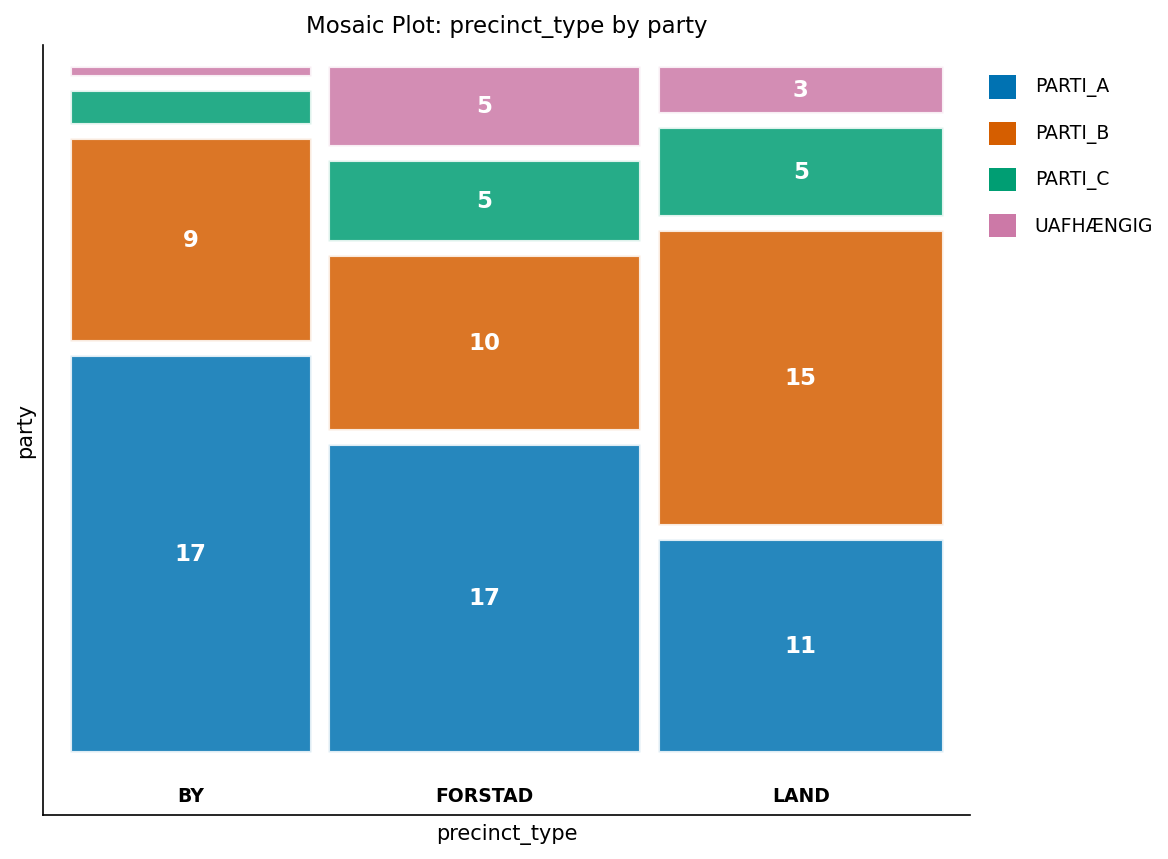

In [7]:
/* --------------------------------------------------------
   Eksportér oversigten over distriktstype x parti til
   efterfølgende vurdering af konsekvenserne af nye
   distriktsgrænser.
   -------------------------------------------------------- */
PROCEDURE FREKVENSER data=work.precinct_votes;
    TABLES precinct_type * party / out=work.voting_pattern_summary nocum;
    MÆRKAT precinct_type = "Distriktstype"
           party = "Parti";
KØR;

PROCEDURE EKSPORTERE data=work.voting_pattern_summary
    OUTFILE='precinct_voting_patterns.csv'
    DBMS=csv REPLACE;
KØR;

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Fortroligt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drevet af <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>